# 변경 Spec 후속 평가 계획
목표 **3,500 Å ± 300 Å**. 모든 Split은 실제 실험 전이며 예측값과 평가 계획입니다.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.detailed_analysis import evaluate_conditions, follow_up_estimate
from src.render_detailed import render
render(ROOT)

## 1. Uniformity≤10% 후보 중 Run19 선정
10%는 분석자의 선별 기준입니다. 이 그룹에서 평균 두께가 가장 큰 조건을 기준점으로 선택합니다.

In [2]:
conditions = evaluate_conditions(pd.read_csv(ROOT/'data/deposition_condition_summary.csv'))
reference_candidates = conditions[conditions.uniformity_pct <= 10].sort_values('average_thickness',ascending=False)
display(reference_candidates)
assert reference_candidates.iloc[0].recipe == 'FT0524_run19'

,recipe,si2h6_flow,power,temperature,time_sec,average_thickness,max_thickness,min_thickness,range,standard_deviation,uniformity_pct,dep_rate_a_per_sec,target_gap_a,observed_points_within_spec
20,FT0524_run19,195,300,300,45,3143.877551,3439.554157,2815.919398,623.634759,183.810590,9.918242,69.863946,56.122449,True
21,FT0524_run20,185,300,300,45,3053.255102,3351.554157,2743.088476,608.465681,180.719635,9.964213,67.850113,146.744898,False
23,FT0524_run22,175,300,300,45,2842.111877,3105.295119,2544.481746,560.813373,167.031233,9.866138,63.158042,357.888123,False


## 2. Power·온도·시간 비교
현재 요약표 기반 변화율과 원본 계획의 반올림 상수 20.8%·14.4%를 구분합니다.

Power dep_rate_a_per_sec    25.089090
uniformity_pct        -5.469767
dtype: float64
Temperature dep_rate_a_per_sec    14.480711
uniformity_pct        20.739900
dtype: float64


,si2h6_flow,power,temperature,time_sec,average_thickness,uniformity_pct,dep_rate_a_per_sec
recipe,,,,,,,
FT0524_run13,175,400,400,30,2988.373878,12.372615,99.612463
FT0524_run14,175,300,400,30,2238.618072,13.049368,74.620602
FT0524_run15,175,300,400,35,2613.781222,13.137107,74.679463
FT0524_run16,175,300,400,40,2981.464080,12.645703,74.536602
FT0524_run21,175,300,300,40,2549.726873,10.022997,63.743172
FT0524_run22,175,300,300,45,2842.111877,9.866138,63.158042
FT0524_run23,175,300,300,50,3154.614376,10.099302,63.092288


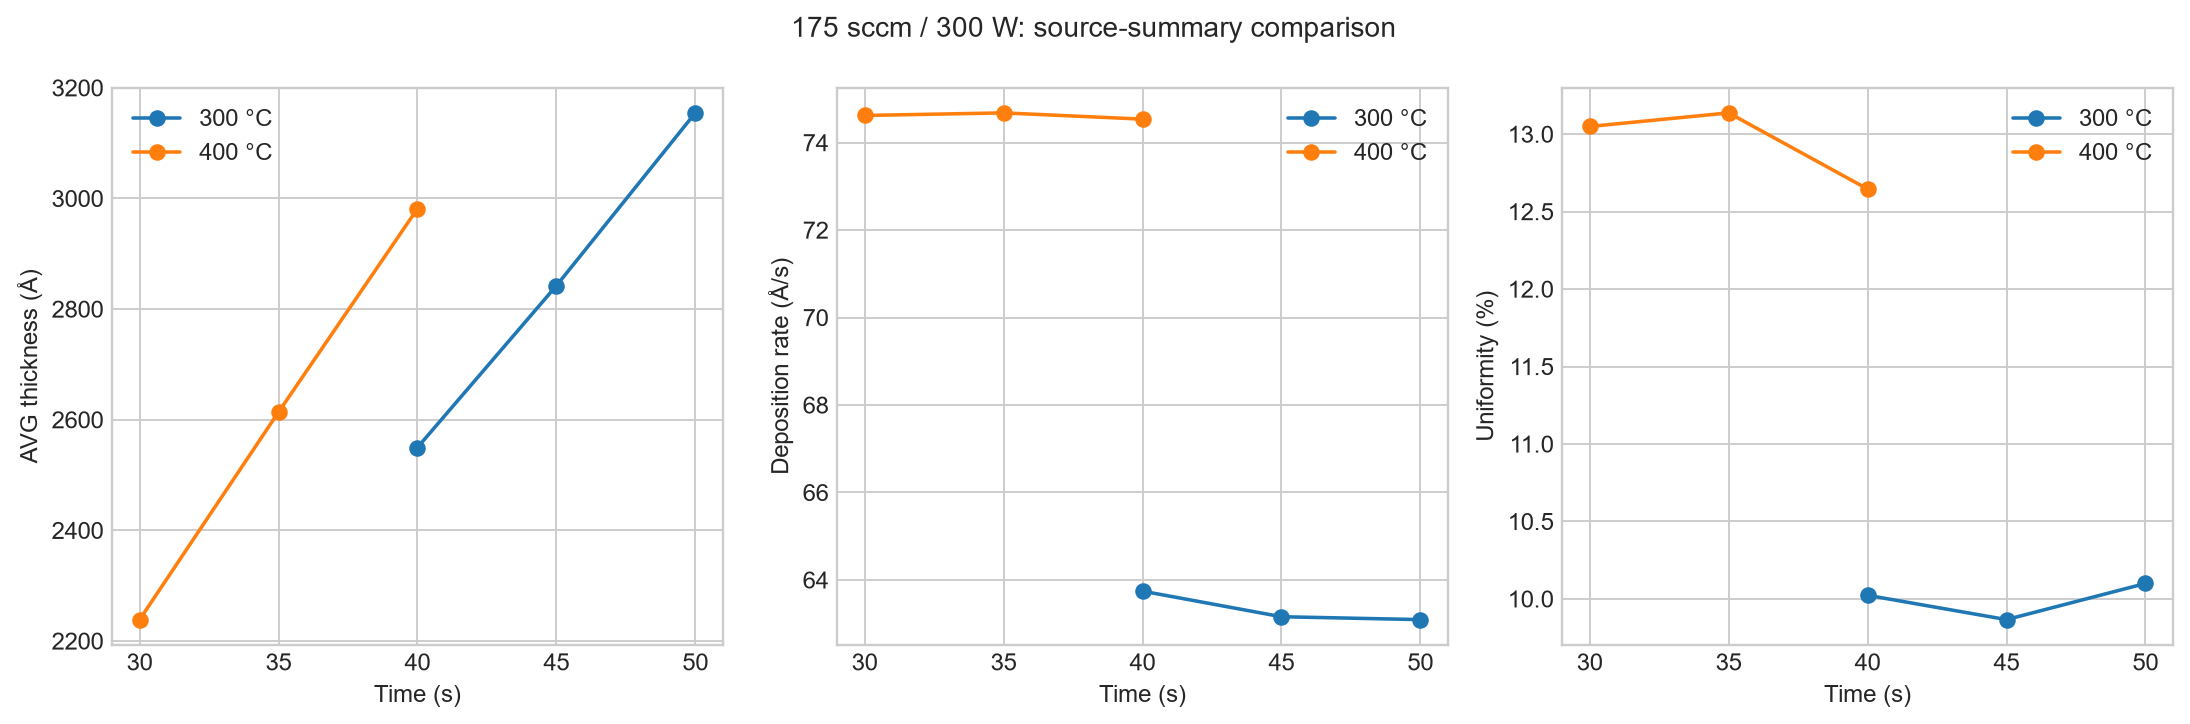

In [3]:
comparison = pd.read_csv(ROOT/'data/parameter_comparison.csv').set_index('recipe')
display(comparison)
for name,before,after in [('Power','FT0524_run13','FT0524_run14'),('Temperature','FT0524_run16','FT0524_run21')]:
    print(name, (1-comparison.loc[after,['dep_rate_a_per_sec','uniformity_pct']]/comparison.loc[before,['dep_rate_a_per_sec','uniformity_pct']])*100)
display(Image(filename=str(ROOT/'images/time_temperature_comparison.png')))

## 3. 원본 평가안 재현
8.57%=300/3500×100은 설계 참고값입니다. 300–400℃ 경향의 외삽, 유량 간 변화율 전이, 시간과 두께 비례를 가정합니다.

In [4]:
estimate = follow_up_estimate()
display(pd.Series(estimate))
assert abs(estimate['predicted_average_a']-3481.197448)<1e-5

reference_uniformity_pct                8.571429
baseline_uniformity_pct                 9.918242
relative_uniformity_reduction_pct      13.579154
temperature_drop_c                     65.284392
calculated_temperature_c              234.715608
rate_reduction_pct                      9.400952
expected_average_at_base_time_a      2848.323116
calculated_time_sec                    55.295693
applied_temperature_c                 234.700000
applied_time_sec                       55.000000
predicted_average_a                  3481.197448
predicted_uniformity_pct                8.571107
dtype: float64

## 4. 전체 Split
New_1-1만 예측값이 있으며 나머지는 미평가입니다. Power·온도 3개 조합×시간 3개로 구성했으므로 Power의 독립 효과를 모두 분리하는 설계는 아닙니다.

In [5]:
display(pd.read_csv(ROOT/'data/follow_up_split_plan.csv'))

,split,si2h6_flow,power,temperature,time_sec,predicted_average_a,predicted_uniformity_pct,status
0,New_1-1,195,300,234.7,55,3481.197448,8.571107,unmeasured
1,New_1-2,195,300,234.7,50,NaN,NaN,unmeasured
2,New_1-3,195,300,234.7,60,NaN,NaN,unmeasured
3,New_2-1,195,400,200.0,55,NaN,NaN,unmeasured
4,New_2-2,195,400,200.0,50,NaN,NaN,unmeasured
5,New_2-3,195,400,200.0,60,NaN,NaN,unmeasured
6,New_3-1,195,400,300.0,55,NaN,NaN,unmeasured
7,New_3-2,195,400,300.0,50,NaN,NaN,unmeasured
8,New_3-3,195,400,300.0,60,NaN,NaN,unmeasured


## 판정 계획
49개 위치의 실측 두께·GOF를 확보하고 MIN≥3,200 Å, MAX≤3,800 Å를 확인합니다. Uniformity만으로 규격 충족을 단정하지 않습니다. 후보 조건을 반복해 예측 오차와 재현성을 확인합니다.